In [2]:
import sys
print(sys.executable)

c:\Users\hp\Desktop\Final Year Project\Crime-Rate-Prediction\venv\Scripts\python.exe


In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import xgboost as xgb

import matplotlib.pyplot as plt

In [7]:

df = pd.read_excel(
    "../data/processed/new_dataset.xlsx"
)

df.head()

,Year,State,City,Population (in Lakhs) (2011)+,Number Of Cases,Type,Crime Rate
0,2014,Gujarat,Ahmedabad,63.5,82,Murder,1.291339
1,2015,Gujarat,Ahmedabad,63.5,94,Murder,1.480315
2,2016,Gujarat,Ahmedabad,63.5,103,Murder,1.622047
3,2017,Gujarat,Ahmedabad,63.5,90,Murder,1.417323
4,2018,Gujarat,Ahmedabad,63.5,98,Murder,1.543307


# PROCESSING

In [8]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
)

df["state"] = (
    df["state"]
    .astype("category")
    .cat.codes
)

df["city"] = (
    df["city"]
    .astype("category")
    .cat.codes
)

df["type"] = (
    df["type"]
    .astype("category")
    .cat.codes
)

# FEATURES

In [11]:
X = df[
    [
        "year",
        "state",
        "city",
        "type"
    ]
]

y = df["number of cases"]

X_train, X_test, y_train, y_test = (
    train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42
    )
)

# MODELS

In [12]:
models = {

    "Linear Regression":
        LinearRegression(),

    "Random Forest":
        RandomForestRegressor(),

    "Gradient Boosting":
        GradientBoostingRegressor(),

    "XGBoost":
        xgb.XGBRegressor()
}

# TRAIN + EVALUATE

In [13]:
results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    mae = mean_absolute_error(
        y_test,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            predictions
        )
    )

    r2 = r2_score(
        y_test,
        predictions
    )

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

# RESULTS

In [14]:
results_df = pd.DataFrame(results)

results_df.sort_values(
    by="RMSE"
)

,Model,MAE,RMSE,R2
3,XGBoost,149.563141,300.372295,0.973961
1,Random Forest,142.983553,332.710845,0.968052
2,Gradient Boosting,482.436898,976.667963,0.724701
0,Linear Regression,929.914586,1798.359965,0.066608


# VISUALIZATION

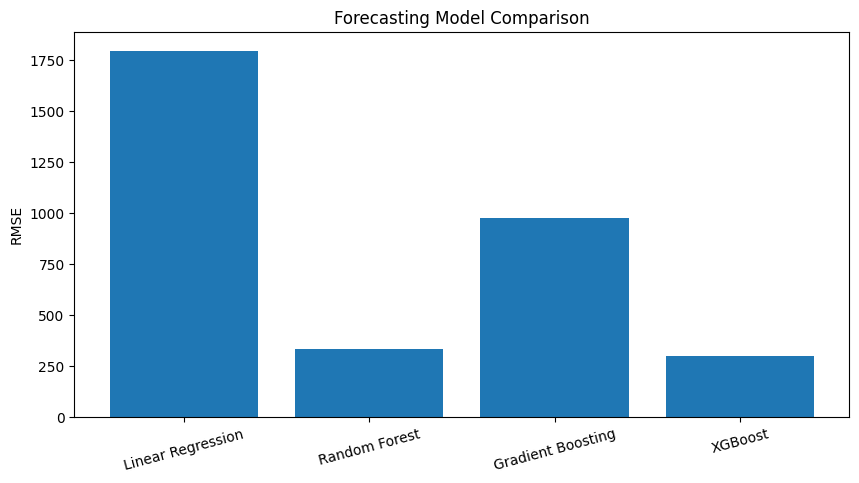

In [15]:
plt.figure(figsize=(10, 5))

plt.bar(
    results_df["Model"],
    results_df["RMSE"]
)

plt.title(
    "Forecasting Model Comparison"
)

plt.ylabel("RMSE")

plt.xticks(rotation=15)

plt.show()